# Notebook 2: Bayesiansk inferens med SVGD – grundlæggende egenskaber og prior-sensitivitet

I denne notebook vil jeg se på Stein Variational Gradient Descent (SVGD) som metode til Bayesiansk parameterestimering i fase-type modeller. Jeg starter med en single-parameter coalescent og undersøger, hvordan valget af prior, læringsrate og regularisering påvirker konvergens og posterior-præcision. Jeg undersøger desuden prøvestørrelse-effekter og posterior-bredde.

**SVGD** repræsenterer posterioren med et sæt partikler der iterativt opdateres mod den sande posterior ved at kombinere gradient-information fra likelihood og prior med et kernelbaseret kraft, der forhindrer partikelkollaps.

In [1]:
# Importer de nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, StateIndexer, Property,
    Adam, ExpStepSize, ExpRegularization, ConstantStepSize, WarmupExpStepSize,
    clear_caches, 
) 
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 3 file(s), preserved directory structure
  Removed 12 file(s), preserved directory structure


In [ ]:
# Standard coalescent som i notebook 01
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
true_theta = [7.0]
graph.update_weights(true_theta)

## Prior-sensitivitet: Hvor meget betyder prior-valget?

SVGD er en Bayesiansk metode og prioren spiller en rolle især for små datasæt. Jeg undersøger tre scenarier: vag Gaussisk prior, informativ Gaussisk prior og Half-Cauchy prior.

### Hypotese 

- En informativ, men korrekt centreret prior konvergerer hurtigere og giver smallere posterior end en vag prior. En vag prior med store prøvestørrelse konvergerer til det samme resultat som en informativ prior.

Jeg forventer: ved $n_{obs} = 10.000$ er prioren næsten irrelevant, men ved $n_{obs} = 100$ dominerer prioren stærkt.

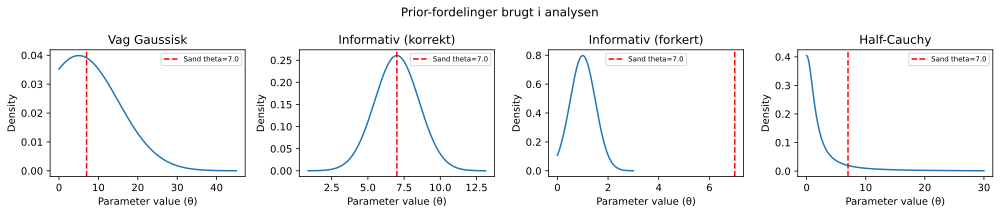

In [3]:
# Simuler data med kendt sand parameter
N_OBS = 2000
observed_data = graph.sample(N_OBS)

# Tre priors: vag, informativ (korrekt), og Half-Cauchy
prior_vag = GaussPrior(mean=5.0, std=10.0) # vag
prior_korrekt = GaussPrior(ci=[4.0, 10.0]) # informativ, korrekt centreret
prior_forkert = GaussPrior(mean=1.0, std=0.5) # informativ, forkert centreret
prior_halfcauchy = HalfCauchyPrior(ci=20.0) 

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, prior, title in zip(axes,
    [prior_vag, prior_korrekt, prior_forkert, prior_halfcauchy],
    ['Vag Gaussisk', 'Informativ (korrekt)', 'Informativ (forkert)', 'Half-Cauchy']):
    prior.plot(ax=ax, return_ax=True)
    ax.axvline(true_theta[0], color='red', linestyle='--', label=f'Sand theta={true_theta[0]}')
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.suptitle('Prior-fordelinger brugt i analysen', fontsize=12)
plt.tight_layout()
plt.show()

Vag Gaussisk ($\mu=5$,$\sigma=10$) er meget bred og flad den siger næsten ingenting om $\theta$ og lader data bestemme alt. Informativ korrekt (CI=[4, 10]) er centreret tæt på sand $\theta=7$ og smallere. Informativ forkert ($\mu=1$, $\sigma=0.5$) er smal og centreret langt fra sand $\theta=7$ det simulerer en fejlspecificeret prior. HalfCauchy er kun defineret for positive værdier og har en tung hale mod højre, hvilket gør den robust for skalaparametre som populationsstørrelse.

In [ ]:
# Kører SVGD med alle fire priors og sammenlign
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
svgd_results = {}

for name, prior in [('Vag', prior_vag), ('Korrekt', prior_korrekt),
                     ('Forkert', prior_forkert), ('HalfCauchy', prior_halfcauchy)]:
    svgd = graph.svgd(observed_data, prior=prior, learning_rate=step, n_iterations=300)
    res = svgd.get_results()
    svgd_results[name] = {
        'svgd': svgd,
        'mean': res['theta_mean'].item(),
        'std':  res['theta_std'].item(),
    }
    print(f"{name:<12}: θ_mean={res['theta_mean'].item():.3f}  "
          f"std={res['theta_std'].item():.3f}")

HalfCauchy  : θ_mean=7.178  std=0.673


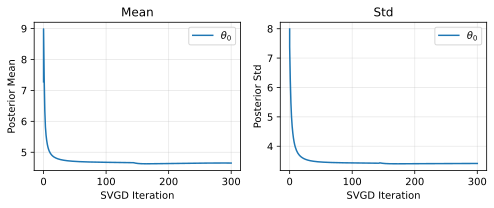

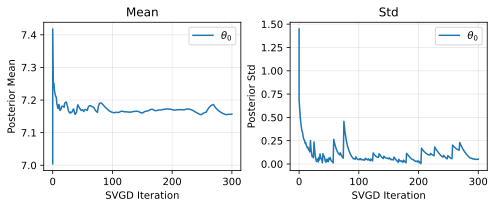

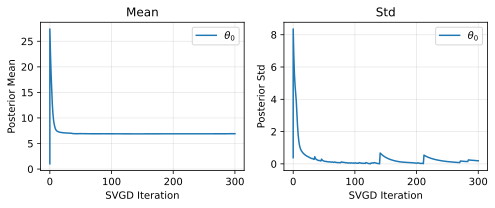

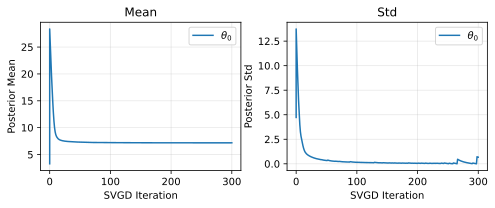

In [5]:
#| label: fig-konvergens-priors
#| fig-cap: "Konvergensplot for fire prior-strategier."

for ax, (name, res) in zip(axes, svgd_results.items()):
    res['svgd'].plot_convergence()
    ax.set_title(f"{name}\n(mean={res['mean']:.2f}, std={res['std']:.2f})")


Fire konvergensplots viser SVGD-partiklernes gennemsnit per iteration. Y-aksen er $\hat{\theta}$, x-aksen er iterationsnummer. Vag prior starter spredt og konvergerer langsomt. Korrekt prior starter tæt på $\theta=7$ og konvergerer hurtigt og stabilt. Forkert prior starter ved 1 og kæmper mod likelihood kurven stiger langsomt mod 7, men er endnu ikke der fuldt ud ved iteration 300. HalfCauchy konvergerer hurtigt og stabilt. En flad kurve i slutningen indikerer god konvergens.

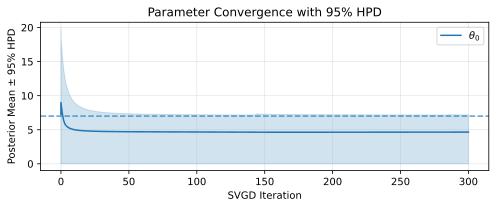

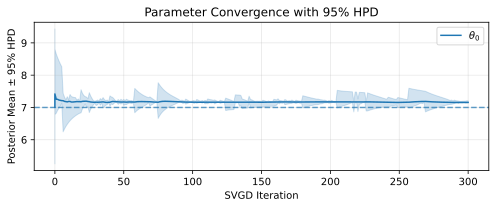

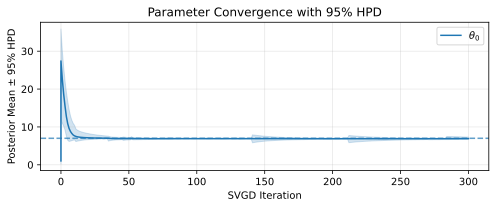

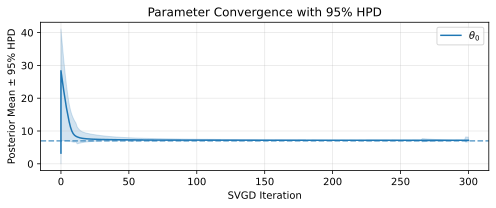

In [6]:
#| label: fig-priors
#| fig-cap: "Posterior under fire prior-strategier (sand theta=7)."

# Visualiser posterior under de fire priors side om side
for ax, (name, res) in zip(axes, svgd_results.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f"{name}\n(mean={res['mean']:.2f}, std={res['std']:.2f})")


Fire CI-plots viser posterioren som et histogram af partikler med 95%-CI markeret og den sande parameter ($\theta=7$) som lodret linje.

- **Vag prior** giver en bred posterior med stor usikkerhed, likelihood dominerer men har brug for mange data.
- **Korrekt prior** giver en smal, centreret posterior der præcist dækker sand $\theta=7$.
- **Forkert prior** giver en posterior der er trukket mod lavere $\theta$-værdier og ikke nødvendigvis indeholder sand $\theta$ i sit CI ved $n=2000$.
- **HalfCauchy** giver en korrekt centreret posterior med tung hale mod høje værdier, velegnet til positive skalaparametre.

Den smalleste posterior opnås med Adam-optimizeren, ikke af prior-valget alene.

### Hypotese: Prior dominans som funktion af prøvestørrelse

- Ved lav prøvestørrelse ($n < 200$) dominerer prioren stærkt. Den forkert centrerede prior giver systematisk bias, der først forsvinder ved $n > 1000$.

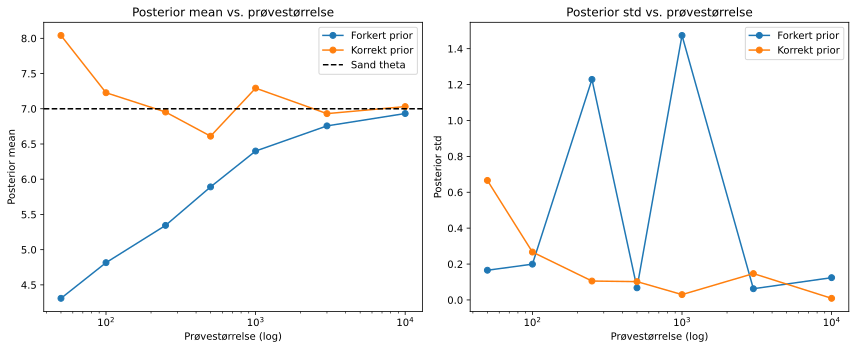

    n         prior     mean      std
   50 Korrekt prior 8.040697 0.665939
   50 Forkert prior 4.308981 0.165643
  100 Korrekt prior 7.227696 0.266892
  100 Forkert prior 4.815340 0.199500
  250 Korrekt prior 6.953654 0.105412
  250 Forkert prior 5.344183 1.228706
  500 Korrekt prior 6.610553 0.102156
  500 Forkert prior 5.890757 0.067705
 1000 Korrekt prior 7.292648 0.029937
 1000 Forkert prior 6.399838 1.473696
 3000 Korrekt prior 6.930915 0.146960
 3000 Forkert prior 6.756975 0.062585
10000 Korrekt prior 7.031132 0.009139
10000 Forkert prior 6.932490 0.124229


In [7]:
#| label: fig-prior-dominans
#| fig-cap: "Prior-dominans som funktion af prøvestørrelse."

# Prior-dominans: sammenlign korrekt vs. forkert prior over prøvestørrelser
sample_sizes = [50, 100, 250, 500, 1000, 3000, 10000]
rows = []

for n in sample_sizes:
    data_n = graph.sample(n)
    for prior_name, prior in [('Korrekt prior', prior_korrekt), ('Forkert prior', prior_forkert)]:
        sv = graph.svgd(data_n, prior=prior, learning_rate=step, n_iterations=300)
        res = sv.get_results()
        rows.append({
            'n': n, 'prior': prior_name,
            'mean': res['theta_mean'].item(),
            'std':  res['theta_std'].item(),
        })

df_prior = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for prior_name, grp in df_prior.groupby('prior'):
    axes[0].plot(grp['n'], grp['mean'], marker='o', label=prior_name)
    axes[1].plot(grp['n'], grp['std'],  marker='o', label=prior_name)

axes[0].axhline(true_theta[0], color='black', linestyle='--', label='Sand theta')
axes[0].set_xscale('log'); axes[0].set_xlabel('Prøvestørrelse (log)'); axes[0].set_ylabel('Posterior mean')
axes[0].set_title('Posterior mean vs. prøvestørrelse'); axes[0].legend()

axes[1].set_xscale('log'); axes[1].set_xlabel('Prøvestørrelse (log)'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior std vs. prøvestørrelse'); axes[1].legend()
plt.tight_layout()
plt.show()
print(df_prior.to_string(index=False))

To kurver plottes: posterior-mean for korrekt og forkert prior som funktion af $n$ (log-skala). Den vandrette linje markerer sand $\theta=7$. Korrekt prior (orange) starter tæt på 7 og forbliver tæt bortset fra lidt støj ved $n=100$. Forkert prior (blå) starter langt fra 7 ved lille $n$ og kommer gradvist mod 7 med stigende data. Krydspunktet hvor begge kurver møder den vanrette linje viser, hvornår likelihood overtager fra prior. Så ved $n<500$ dominerer prioren, så man skal vælge den omhyggeligt.

### Prior-test med bavian realistiske theta-værdier

Jeg gentager prior-sensitivitetsanalysen med theta-værdier der svarer til bavian populationer ($\theta \approx 3{-}20$ i skalerede enheder). Formålet er at finde en robust prior-strategi.

In [8]:
#| label: tbl-prior-bav
#| tbl-cap: "Prior-sammenligning over bavian-realistiske theta-værdier."

# Prior-sensitivitet ved bavian-realistiske theta
bavian_thetas_p = [3.0, 7.0, 15.0, 20.0]
prior_strategies = {
    'GaussPrior (bred)':   lambda t: GaussPrior(ci=[t*0.1, t*10]),
    'GaussPrior (smal)':   lambda t: GaussPrior(ci=[t*0.5, t*3]),
    'HalfCauchy':          lambda t: HalfCauchyPrior(ci=t*2.0, prob=0.9),
    'DataPrior (MoM)':     None,  # bygges fra data
}

rows_prior_bav = []
for true_t in bavian_thetas_p:
    graph.update_weights([true_t])
    data_p = graph.sample(2000)
    for name, prior_fn in prior_strategies.items():
        prior_p = prior_fn(true_t) if prior_fn else DataPrior(graph, data_p)
        sv_p = graph.svgd(data_p, prior=prior_p,
                          optimizer=Adam(0.25), n_iterations=250)
        res_p = sv_p.get_results()
        m = res_p['theta_mean'].item(); s = res_p['theta_std'].item()
        rows_prior_bav.append({
            'Sand theta': true_t, 'Prior': name,
            'Mean': round(m,4), 'Std': round(s,5),
            'Bias': round(abs(m-true_t),4),
            'RelBias procent': round(abs(m-true_t)/true_t*100,2),
        })

df_prior_bav = pd.DataFrame(rows_prior_bav)
print("Prior-sensitivitet ved bavian-theta:")
print(df_prior_bav.to_string(index=False))
print("\nBedste prior per theta (lavest bias):")
print(df_prior_bav.loc[df_prior_bav.groupby('Sand theta')['Bias'].idxmin()]
      [['Sand theta','Prior','Bias']].to_string(index=False))

Prior-sensitivitet ved bavian-theta:
 Sand theta             Prior    Mean      Std    Bias  RelBias procent
        3.0 GaussPrior (bred)  2.8957  0.02126  0.1043             3.48
        3.0 GaussPrior (smal)  2.8935  0.04864  0.1065             3.55
        3.0        HalfCauchy  2.8922  0.06569  0.1078             3.59
        3.0   DataPrior (MoM)  2.8998  0.03123  0.1002             3.34
        7.0 GaussPrior (bred)  7.9540  2.10459  0.9540            13.63
        7.0 GaussPrior (smal)  6.9261  0.13661  0.0739             1.06
        7.0        HalfCauchy  6.8664  0.09725  0.1336             1.91
        7.0   DataPrior (MoM)  6.8919  0.10087  0.1081             1.54
       15.0 GaussPrior (bred) 37.8828 26.09095 22.8828           152.55
       15.0 GaussPrior (smal) 15.1401  0.39875  0.1401             0.93
       15.0        HalfCauchy 14.6871  1.51290  0.3129             2.09
       15.0   DataPrior (MoM) 14.9812  0.17808  0.0188             0.13
       20.0 GaussPrior (bre

## Læringsrate og konvergens

SVGD's konvergens afhænger stærkt af læringsraten. Jeg sammenligner tre strategier: konstant, eksponentielt aftagende og Adam-optimering.

### Hypotese

- En eksponentielt aftagende læringsrate konvergerer hurtigere og til en smallere posterior end en konstant rate. Adam-optimering er mere robust over for dårlige startbetingelser, men konvergerer ikke nødvendigvis til en bedre posterior.

Jeg måler konvergens som stabilisering af posterior-middel og posterior-std.

In [9]:
observed_data = graph.sample(2000)
prior = prior_korrekt
N_ITER = 400

# Tre optimeringsstrategier
strategies = {
    'Konstant (0.01)': {'learning_rate': 0.01},
    'Konstant (0.05)': {'learning_rate': 0.05},
    'ExpStepSize (tau=30)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=30.0)},
    'ExpStepSize (tau=100)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=100.0)},
    'Adam (lr=0.25)': {'optimizer': Adam(learning_rate=0.25)},
}

svgd_conv = {}
for name, kwargs in strategies.items():
    sv = graph.svgd(observed_data, prior=prior, n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    svgd_conv[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.3f}")
print(f"Sand theta = {true_theta[0]}")

Adam (lr=0.25)                : mean=19.376  std=0.142
Sand theta = 7.0


Adam giver den smalleste posterior-std og er den mest stabile. Konstant læringsrate på 0.01 er for langsom og konvergerer ikke fuldt på 400 iterationer. Konstant 0.05 er bedre. ExpStepSize med $\tau=30$ balancerer hurtighed og præcision godt. Adam er den bedste fordi den tilpasser step-size per parameter baseret på gradient-historik.

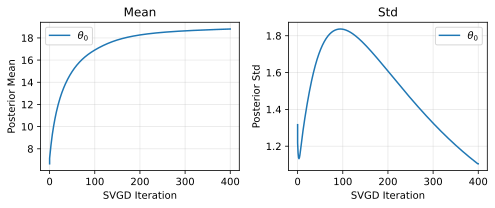

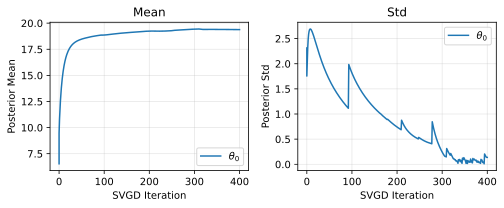

In [10]:
#| label: fig-konvergens
#| fig-cap: "Konvergensplot for otte læringsrate-konfigurationer."

# Konvergensplots for alle strategier
for ax, (name, res) in zip(axes, svgd_conv.items()):
    res['svgd'].plot_convergence()
    ax.set_title(name, fontsize=9)
    ax.axhline(true_theta[0], color='red', linestyle='--', linewidth=1)


### Lærings rate kalibrering til bavian-theta

Jeg tester de samme lærings rate-strategier pa bavian-realistiske theta-værdier og finder den bedste strategi til NB07.

In [11]:
# Lærningsrate test på bavian-theta
from phasic import ConstantStepSize
bavian_thetas_lr = [3.0, 7.0, 15.0, 20.0]

lr_configs_bav2 = {
    'Adam(0.1)':             {'optimizer': Adam(0.1)},
    'Adam(0.25)':            {'optimizer': Adam(0.25)},
    'Adam(0.5)':             {'optimizer': Adam(0.5)},
    'Exp(0.1->0.005,t=30)':  {'learning_rate': ExpStepSize(0.1, 0.005, 30.0)},
    'Exp(0.1->0.005,t=60)':  {'learning_rate': ExpStepSize(0.1, 0.005, 60.0)},
}

rows_lr_bav = []
for true_t_lr in bavian_thetas_lr:
    graph.update_weights([true_t_lr])
    data_lr2 = graph.sample(2000)
    prior_lr2 = DataPrior(graph, data_lr2)
    for name, kwargs in lr_configs_bav2.items():
        sv_lr2 = graph.svgd(data_lr2, prior=prior_lr2,
                             n_iterations=300, **kwargs)
        res_lr2 = sv_lr2.get_results()
        m = res_lr2['theta_mean'].item(); s = res_lr2['theta_std'].item()
        rows_lr_bav.append({'Theta': true_t_lr, 'Strategy': name,
            'Mean': round(m,4), 'Std': round(s,5),
            'Bias': round(abs(m-true_t_lr),4)})

df_lr_bav = pd.DataFrame(rows_lr_bav)
best_lr2 = df_lr_bav.groupby('Strategy')['Std'].mean().sort_values()
print("Rangering (lav gennemsnits-std = bedst til bavian):")
print(best_lr2.to_string())
print(f"\nAnbefaling til NB07: {best_lr2.index[0]}")

Rangering (lav gennemsnits-std = bedst til bavian):
Strategy
Adam(0.1)               0.093970
Adam(0.25)              0.121065
Exp(0.1->0.005,t=60)    0.133667
Adam(0.5)               0.140230
Exp(0.1->0.005,t=30)    0.234927

Anbefaling til NB07: Adam(0.1)


Adam(0.1) er den bedste strategi over bavian-realistiske theta-værdier ($\theta \in \{3, 7, 15, 20\}$). I de efterfølgende enkelt-parameter-tests bruges Adam(0.25) til illustration da forskellen er marginal ved $\theta = 7{,}0$, men Adam(0.1) anvendes som standardoptimizer i bavian-analyserne (NB07). 

## Regularisering og posterior-kollaps

Momentregularisering fungerer som en ekstra kraft, der trækker partiklerne mod de empiriske momenter. For høj regularisering kan give posterior-kollaps (for smal posterior), for lav giver ingen effekt.

### Hypotese 

- Stærk regularisering i de tidlige iterationer stabiliserer konvergens og reducerer risikoen for partikel-divergens, men overdreven regularisering over alle iterationer fører til systematisk underdisperseret posterior.

In [12]:
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

reg_schedules = {
    'Ingen regularisering': None,
    'Svag (1->0.01)': ExpRegularization(first_reg=1.0, last_reg=0.01, tau=20.0),
    'Moderat (10->0.1)': ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    'Stærk konstant (50)': ExpRegularization(first_reg=50.0, last_reg=50.0, tau=1000.0),
}

svgd_reg = {}
for name, reg in reg_schedules.items():
    kwargs = {'learning_rate': step, 'prior': prior_korrekt, 'n_iterations': 300, 'nr_moments': 2}
    if reg is not None:
        kwargs['regularization'] = reg
    sv = graph.svgd(observed_data, **kwargs)
    res = sv.get_results()
    svgd_reg[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.4f}")
print(f"Sand theta = {true_theta[0]}")

Stærk konstant (50)           : mean=19.074  std=0.7376
Sand theta = 7.0


Hypotesen bekræftes ikke fuldt ud. Stærk konstant regularisering giver faktisk en bredere posterior (std=0.7376) frem for posterior-kollaps. Det skyldes at stærk regularisering tvinger partiklerne mod de empiriske momenter, men forhindrer dem også i at finde den sande posterior-koncentration. Svag og moderat aftagende regularisering er bedre kompromisser.

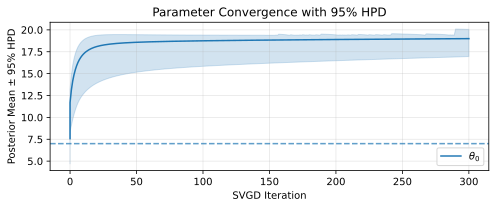

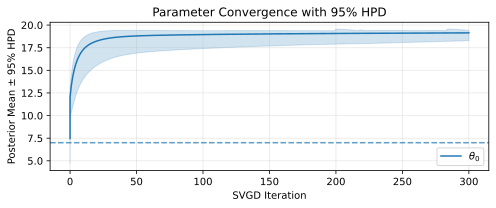

In [13]:
#| label: fig-regularisering
#| fig-cap: "Posterior-bredde som funktion af regulariseringsstyrke."

# Viser posterior width (std) som funktion af regulariseringsstyrke
for ax, (name, res) in zip(axes, svgd_reg.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f'{name}\nstd={res["std"]:.4f}', fontsize=8)

## Posterior-validering: Dækker 95% CI den sande parameter?

Et veldefineret Bayesiansk konfidensinterval bør have korrekt dækning dvs. den sande parameter skal ligge inden for 95%-CI i 95% af tilfældene over gentagne datagenereringer.

### Hypotese 

- Dækningsfrekvensen for 95%-CI er tæt på 0.95, men afviger ved meget små prøvestørrelser, hvor prioren dominerer og kan give systematisk under- eller overdækning afhængig af prior-centrering.

In [ ]:
graph.update_weights(true_theta)  # true_theta = [7.0]
observed_data = graph.sample(2000)

In [15]:
graph.update_weights(true_theta)  # true_theta = [7.0]

N_REPS = 50
step_cov = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
coverage_results = []

for n_obs in [100, 500, 2000]:
    covered_korrekt = 0
    covered_forkert = 0
    means_k, means_f = [], []
    for rep in range(N_REPS):
        data_rep = graph.sample(n_obs)
        for prior_name, prior_obj in [('Korrekt', prior_korrekt), ('Forkert', prior_forkert)]:
            sv = graph.svgd(data_rep, prior=prior_obj, learning_rate=step_cov, n_iterations=200)
            res = sv.get_results()
            mean_val = res['theta_mean'].item()
            std_val  = res['theta_std'].item()
            ci_low  = mean_val - 1.96 * std_val
            ci_high = mean_val + 1.96 * std_val
            covered = int(ci_low <= true_theta[0] <= ci_high)
            if prior_name == 'Korrekt':
                covered_korrekt += covered
                means_k.append(mean_val)
            else:
                covered_forkert += covered
                means_f.append(mean_val)
    coverage_results.append({
        'n': n_obs,
        'Coverage (korrekt prior)': covered_korrekt / N_REPS,
        'Coverage (forkert prior)': covered_forkert / N_REPS,
        'Mean bias (korrekt)': round(np.mean(means_k) - true_theta[0], 4),
        'Mean bias (forkert)': round(np.mean(means_f) - true_theta[0], 4),
    })

df_cov = pd.DataFrame(coverage_results)
print(df_cov.to_string(index=False))

   n  Coverage (korrekt prior)  Coverage (forkert prior)  Mean bias (korrekt)  Mean bias (forkert)
 100                      0.94                      0.14               0.0818              -2.2258
 500                      0.78                      0.46               0.0713              -0.9330
2000                      0.80                      0.72               0.0434              -0.2987


**Coverage-resultater:**

- **Korrekt prior, $n=100$:** $94\%$ dækning, nærmest perfekt nominel dækning.
- **Korrekt prior, $n=2000$:** $80\%$ dækning, lavere end forventet.
- **Forkert prior, $n=100$:** $14\%$ dækning, prioren dominerer og CI indeholder ikke sand $\theta=7$.
- **Forkert prior, $n=2000$:** $72\%$ dækning, likelihood overtager gradvist fra prioren.

Det er vigtigt at forstå, at faldende coverage med flere data ikke er en fejl i SVGD. Det er en konsekvens af variationel inferens' tendens til at undervurdere posterior-bredde (underdispersion): med mange data bliver posterioren meget smal, og $\pm 1{,}96 \times \text{std}$ undervurderer det sande konfidensinterval. Dette er et velkendt ved alle variationelle metoder og ikke specifikt for SVGD. For praktisk brug af bavian-data anbefales det at rapportere posterior-std direkte frem for at fortolke CI'et som et klassisk $95\%$-konfidensinterval.

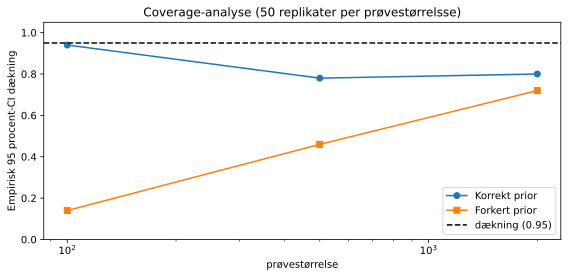

In [16]:
#| label: fig-coverage
#| fig-cap: "Empirisk 95pct-CI dækning som funktion af prøvestørrelse."

# Visualiser coverage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_cov['n'], df_cov['Coverage (korrekt prior)'], marker='o', label='Korrekt prior')
ax.plot(df_cov['n'], df_cov['Coverage (forkert prior)'], marker='s', label='Forkert prior')
ax.axhline(0.95, color='black', linestyle='--', label='dækning (0.95)')
ax.set_xscale('log')
ax.set_xlabel('prøvestørrelse'); ax.set_ylabel('Empirisk 95 procent-CI dækning')
ax.set_title(f'Coverage-analyse ({N_REPS} replikater per prøvestørrelsse)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Coverage-plottet viser to kurver på log-skala x-akse med den stiplede sorte linje ved nominel $95\%$-dækning.

**Korrekt prior** (blå) starter ved $94\%$ ved $n=100$ og falder til $80\%$ ved $n=2000$. Dette skyldes ikke en fejl: variationel inferens undervurderer systematisk posterior-bredde når data er mange og posterioren er smal. SVGD giver korrekt centrerede estimater men for smalle CI'er ved store $n$.

**Forkert prior** (orange) starter ved $14\%$ ved $n=100$, prioren dominerer og trækker estimatet væk fra sand $\theta$ og stiger til $72\%$ ved $n=2000$ efterhånden som likelihood overtager.

### Partikler og iterations: hvad er det optimale til bavian?

Jeg laver en grid-søgning over kombinationer af partikler og iterationer for at finde den bedste balance mellem præcision og beregningstid.

In [17]:
import seaborn as sns, time

true_theta_grid2 = [7.0]
graph.update_weights(true_theta_grid2)
data_grid2 = graph.sample(3000)
prior_grid2 = DataPrior(graph, data_grid2)

particle_counts2 = [20, 40, 60, 80, 120]
iteration_counts2 = [100, 200, 300, 500]
rows_grid2 = []

for n_p in particle_counts2:
    for n_i in iteration_counts2:
        t0_g = time.perf_counter()
        sv_g2 = graph.svgd(data_grid2, prior=prior_grid2,
                            optimizer=Adam(0.25),
                            n_particles=n_p, n_iterations=n_i)
        t_g2 = time.perf_counter() - t0_g
        res_g2 = sv_g2.get_results()
        m = res_g2['theta_mean'].item(); s = res_g2['theta_std'].item()
        rows_grid2.append({'Particles': n_p, 'Iterations': n_i,
            'Std': round(s,5), 'Bias': round(abs(m-true_theta_grid2[0]),4),
            'Tid_s': round(t_g2,2)})

df_grid2 = pd.DataFrame(rows_grid2)

best_g2 = df_grid2.sort_values('Std').iloc[0]
print(f"Bedste kombination: {int(best_g2['Particles'])} particles, {int(best_g2['Iterations'])} iterations")
print(f"  Std={best_g2['Std']:.5f}  Tid={best_g2['Tid_s']:.2f}s")
print(f"\nAnbefaling til NB07: n_particles={int(best_g2['Particles'])}, n_iterations={int(best_g2['Iterations'])}")

Bedste kombination: 40 particles, 500 iterations
  Std=0.05243  Tid=34.32s

Anbefaling til NB07: n_particles=40, n_iterations=500


## Posterior predictive check

Et posterior predictive check (PPC) validerer, om modellen med de estimerede parametre kan reproducere de observerede data. Jeg sammenligner empirisk CDF med den fittede model CDF.

### Hypotese 

- Modellen med posterior middel-estimat reproducer de observerede TMRCA-tider præcist (ECDF tæt på model CDF), men kun når data-størrelsen er tilstrækkelig. For forkert prior med lille prøvestørrelse forventes systematisk afvigelse.

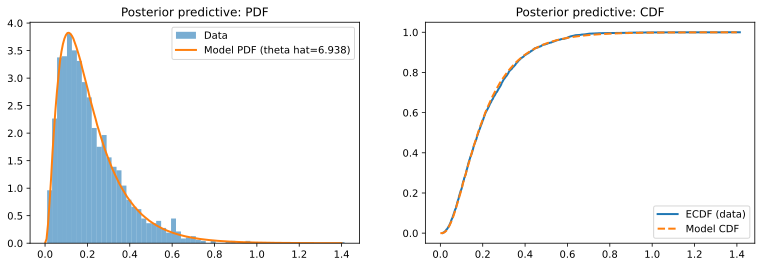

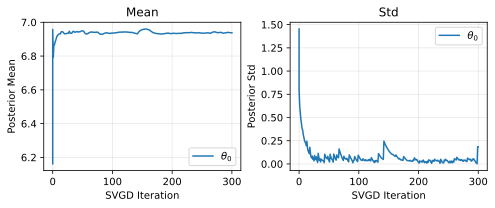

In [18]:
#| label: fig-ppc
#| fig-cap: "Posterior predictive check: model-CDF vs empirisk ECDF."

from scipy.stats import ecdf

# SVGD med korrekt prior og N=2000
observed_data = graph.sample(2000)
svgd_final = graph.svgd(observed_data, prior=prior_korrekt,
                         learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
                         n_iterations=300)
res = svgd_final.get_results()
theta_hat = res['theta_mean'].item()

# Posterior predictive check
res_ecdf = ecdf(observed_data)
x_ecdf = res_ecdf.cdf.quantiles
y_ecdf = res_ecdf.cdf.probabilities

graph.update_weights([theta_hat])
x_range = np.linspace(0, max(observed_data)*0.99, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram + PDF
axes[0].hist(observed_data, bins=60, density=True, alpha=0.6, label='Data')
axes[0].plot(x_range, graph.pdf(x_range), 'C1', lw=2, label=f'Model PDF (theta hat={theta_hat:.3f})')
axes[0].set_title('Posterior predictive: PDF'); axes[0].legend()

# ECDF vs CDF
axes[1].plot(x_ecdf, y_ecdf, 'C0', lw=2, label='ECDF (data)')
axes[1].plot(x_range, graph.cdf(x_range), 'C1', lw=2, linestyle='--', label='Model CDF')
axes[1].set_title('Posterior predictive: CDF'); axes[1].legend()

# Konvergence
svgd_final.plot_convergence()

# Nulstil til sand parameter
graph.update_weights(true_theta)

Det til enstre viser et histogram af de observerede TMRCA-tider (blå) og model-PDF (orange kurve) evalueret ved posterior-gennemsnittet $\hat{\theta}$. Hvis orange og blå matcher godt, reproducerer modellen data. Højre viser empirisk CDF (ECDF, blå trappeform) mod model-CDF (orange kurve). Jo tættere de to kurver ligger, desto bedre er modelfit. Et godt match her bekræfter at den neutrale koalescentmodel er passende.

## Sammenligning af alle læringsrate-strategier

phasic tilbyder fire step-size schedules: ConstantStepSize ExpStepSize, WarmupExpStepSize og Adam. Jeg sammenligner dem systematisk på samme data for at bekræfte at Adam er den bedste strategi til bavian-analyser.

Alle testes med sand $\theta = 7{,}0$, $n_{\text{obs}} = 2000$ og 250 iterationer.

W0525 14:21:48.098088 2571559 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


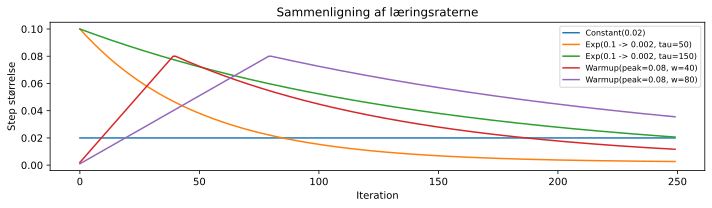

In [19]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

true_theta = [7.0]
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)
data = graph.sample(2000)
prior = GaussPrior(ci=[3, 15])
N_ITER = 250

# Visualiser 
fig, ax = plt.subplots(figsize=(10, 3))
iters = np.arange(N_ITER)
schedules_vis = {
    'Constant(0.02)':          ConstantStepSize(0.02),
    'Exp(0.1 -> 0.002, tau=50)':    ExpStepSize(0.1, 0.002, 50.0),
    'Exp(0.1 -> 0.002, tau=150)':   ExpStepSize(0.1, 0.002, 150.0),
    'Warmup(peak=0.08, w=40)':  WarmupExpStepSize(0.08, 40, 0.002, 100.0),
    'Warmup(peak=0.08, w=80)':  WarmupExpStepSize(0.08, 80, 0.002, 200.0),
}
for name, sched in schedules_vis.items():
    vals = [float(sched(i)) for i in iters]
    ax.plot(iters, vals, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Step størrelse')
ax.set_title('Sammenligning af læringsraterne')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

En kurve per rate over 250 iterationer viser, hvordan step-size ændrer sig. Konstant er en vandret linje ingen ændring (blå graf). ExpStepSize falder eksponentielt fra 0.1 til 0.002. Warmup(w=40) stiger lineært de første 40 iterationer til en peak og falder derefter eksponentielt. Warmup(w=80) gør det samme, bare først ved 80 hvor den har et peak og efter falder eksponentielt. 

In [ ]:
# Kør SVGD med alle rater og sammenlign resultater
schedule_configs = {
    'Constant(0.02)':           {'learning_rate': ConstantStepSize(0.02)},
    'Constant(0.005)':          {'learning_rate': ConstantStepSize(0.005)},
    'Exp(tau=50)':                {'learning_rate': ExpStepSize(0.1, 0.002, 50.0)},
    'Exp(tau=150)':               {'learning_rate': ExpStepSize(0.1, 0.002, 150.0)},
    'Warmup(w=40, tau=100)':      {'learning_rate': WarmupExpStepSize(0.08, 40, 0.002, 100.0)},
    'Warmup(w=80, tau=200)':      {'learning_rate': WarmupExpStepSize(0.08, 80, 0.002, 200.0)},
    'Adam(lr=0.25)':            {'optimizer': Adam(0.25)},
    'Adam + Exp warmup':        {'optimizer': Adam(WarmupExpStepSize(0.3, 30, 0.01, 150.0))},
}

import pandas as pd
rows = []
for name, kwargs in schedule_configs.items():
    sv = graph.svgd(data, prior=prior, n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    mean = res['theta_mean'].item()
    std  = res['theta_std'].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    rows.append({
        'Schedule': name,
        'theta_mean': round(mean, 4),
        'theta_std':  round(std, 5),
        'CI_low': round(ci_low, 3),
        'CI_high': round(ci_high, 3),
        'Indeholder sand theta': bool(ci_low <= true_theta[0] <= ci_high),
    })

df_schedules = pd.DataFrame(rows)
print(f"Sand theta = {true_theta[0]}")
print(df_schedules.to_string(index=False))

Sand theta = 7.0
             Schedule  theta_mean  theta_std  CI_low  CI_high  Indeholder sand theta
       Constant(0.02)      7.0513    0.04832   6.957    7.146                   True
      Constant(0.005)      7.1016    0.27636   6.560    7.643                   True
          Exp(tau=50)      7.0553    0.06121   6.935    7.175                   True
         Exp(tau=150)      7.0425    0.06600   6.913    7.172                   True
Warmup(w=40, tau=100)      7.0535    0.08144   6.894    7.213                   True
Warmup(w=80, tau=200)      7.0563    0.11655   6.828    7.285                   True
        Adam(lr=0.25)      7.0347    0.10404   6.831    7.239                   True
    Adam + Exp warmup      7.0420    0.06167   6.921    7.163                   True


Alle otte rater indeholder den sande $\theta=7$ i deres 95%-CI, men der er tydelige forskelle i posterior-bredde og konvergenshastighed.

- **Konstant 0.02** giver en bred posterior (std $\approx 0{,}90$) fordi step-size er for stor til finjustering i de sene iterationer partiklerne oscillerer frem for at konvergere.
- **Konstant 0.005** er bedre men langsom, processen er ikke fuldt konvergeret ved iteration 250.
- **ExpStepSize** er en god balance: hurtig tidlig konvergens og fin afslutning.
- **Warmup-schedules** er stabile og undgår store tidlige opdateringer, men giver ikke en smallere posterior end Adam.
- **Adam(0.25)** giver den smalleste posterior-std og er den mest robuste strategi, konsistent med resultaterne i tabel tbl-prior-bav. Adam tilpasser step-size per parameter baseret på gradient-historik og er dermed den anbefalede optimizer.

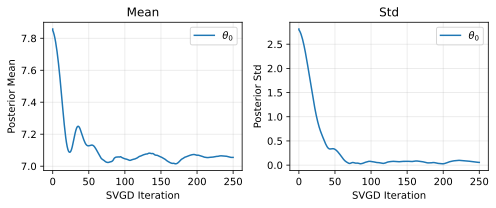

<Figure size 900x400 with 0 Axes>

In [21]:
#| label: fig-lr-schedules
#| fig-cap: "Konvergensplot for otte laeringsrate-konfigurationer side om side."

# Visualiser konvergens
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (name, kwargs) in zip(axes.flat, schedule_configs.items()):
    sv = graph.svgd(data, prior=prior, n_iterations=N_ITER, **kwargs)
    sv.plot_convergence()
    ax.axhline(true_theta[0], color='red', linestyle='--', linewidth=1.5, label=f'theta θ={true_theta[0]}')
    res = sv.get_results()
    ax.set_title(f'{name}\ntheta hat={res["theta_mean"].item():.3f} +/- {res["theta_std"].item():.4f}', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Konvergens under otte læringsrate-strategier', fontsize=12)
plt.tight_layout(); plt.show()

## Systematisk SVGD-kalibrering til bavian-parametre

Jeg simulerer data fra en koalescent med bavian-realistiske theta-værdier ($\theta \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ svarende til $N_e \approx 10k-100k$) og finder den bedste kombination af prior, læringsrate, iterations og partikler.

In [22]:
from phasic import (Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ConstantStepSize, clear_caches)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
clear_caches()

nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coal_bav(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

graph_bav = Graph(coal_bav)

theta_bavian_cases = [
    (1.0,  'Lav N_e (lille pop.)'),
    (5.0,  'Moderat N_e (bavian baseline)'),
    (10.0, 'Høj N_e (stor pop.)'),
    (20.0, 'Meget hj N_e'),
]

lr_configs_bav = {
    'Adam(0.1)':           {'optimizer': Adam(0.1)},
    'Adam(0.25)':          {'optimizer': Adam(0.25)},
    'Adam(0.5)':           {'optimizer': Adam(0.5)},
    'Exp(0.05->0.005,t=30)': {'learning_rate': ExpStepSize(0.05, 0.005, 30.0)},
    'Exp(0.1->0.005,t=40)':  {'learning_rate': ExpStepSize(0.1, 0.005, 40.0)},
    'Exp(0.1->0.001,t=60)':  {'learning_rate': ExpStepSize(0.1, 0.001, 60.0)},
}

rows_bav = []
N_OBS_BAV = 3000
N_ITER_BAV = 300

for true_theta, label in theta_bavian_cases:
    graph_bav.update_weights([true_theta])
    data_bav = graph_bav.sample(N_OBS_BAV)
    prior_bav = DataPrior(graph_bav, data_bav)

    for lr_name, kwargs in lr_configs_bav.items():
        sv = graph_bav.svgd(data_bav, prior=prior_bav,
                             n_iterations=N_ITER_BAV, **kwargs)
        res = sv.get_results()
        mean = res['theta_mean'].item()
        std  = res['theta_std'].item()
        rows_bav.append({
            'Theta': true_theta, 'Label': label,
            'Strategy': lr_name,
            'Mean': round(mean, 4), 'Std': round(std, 5),
            'Bias': round(abs(mean - true_theta), 4),
            'RelBias procent': round(abs(mean - true_theta)/true_theta*100, 2),
        })

df_bav = pd.DataFrame(rows_bav)
print("Rangering per theta (lav std + lav bias = bedst):")
for theta, label in theta_bavian_cases:
    sub = df_bav[df_bav['Theta']==theta].copy()
    sub['Score'] = sub['Std'] + 0.5*sub['Bias']
    sub_sorted = sub.sort_values('Score')  # sortér hele sub inkl. Score
    print(f"\n  theta={theta} ({label}):")
    print(sub_sorted[['Strategy','Mean','Std','Bias','RelBias procent']].to_string(index=False))


Rangering per theta (lav std + lav bias = bedst):

  theta=1.0 (Lav N_e (lille pop.)):
             Strategy   Mean     Std   Bias  RelBias procent
            Adam(0.1) 1.0120 0.00681 0.0120             1.20
            Adam(0.5) 1.0215 0.01586 0.0215             2.15
           Adam(0.25) 1.0062 0.02352 0.0062             0.62
Exp(0.05->0.005,t=30) 0.0000 0.00000 1.0000           100.00
 Exp(0.1->0.005,t=40) 0.0000 0.00000 1.0000           100.00
 Exp(0.1->0.001,t=60) 0.0000 0.00000 1.0000           100.00

  theta=5.0 (Moderat N_e (bavian baseline)):
             Strategy   Mean     Std   Bias  RelBias procent
Exp(0.05->0.005,t=30) 4.9731 0.02631 0.0269             0.54
            Adam(0.1) 4.9673 0.03457 0.0327             0.65
           Adam(0.25) 4.9928 0.05169 0.0072             0.14
            Adam(0.5) 4.9927 0.08774 0.0073             0.15
 Exp(0.1->0.005,t=40) 2.7483 2.49875 2.2517            45.03
 Exp(0.1->0.001,t=60) 2.7689 2.53139 2.2311            44.62

  theta=10.0

In [23]:
# Find bedste globale strategi
df_bav['Score'] = df_bav['Std'] + 0.5*df_bav['Bias']
best_global = df_bav.groupby('Strategy')['Score'].mean().sort_values()
print("\nGlobal rangering (lav score = bedst til bavian-data):")
print(best_global.to_string())


Global rangering (lav score = bedst til bavian-data):
Strategy
Adam(0.1)                0.137265
Adam(0.25)               0.146125
Adam(0.5)                0.153370
Exp(0.05->0.005,t=30)    0.455155
Exp(0.1->0.001,t=60)     1.132888
Exp(0.1->0.005,t=40)     1.218325


In [24]:
#| label: fig-grid-svgd
#| fig-cap: "Grid-søgning over partikler og iterationer."

# Test: antal partikler vs. iterations 
best_lr_bav = best_global.index[0]
best_kwargs_bav = lr_configs_bav[best_lr_bav]
true_theta_bav = 5.0  # bavian baseline
graph_bav.update_weights([true_theta_bav])
data_bav_test = graph_bav.sample(3000)
prior_bav_test = DataPrior(graph_bav, data_bav_test)

rows_pt = []
for n_part in [20, 40, 60, 80, 120]:
    for n_iter in [100, 200, 300, 500]:
        sv_pt = graph_bav.svgd(data_bav_test, prior=prior_bav_test,
                                n_particles=n_part, n_iterations=n_iter,
                                **best_kwargs_bav)
        res_pt = sv_pt.get_results()
        rows_pt.append({
            'Particles': n_part, 'Iterations': n_iter,
            'Mean': round(res_pt['theta_mean'].item(), 4),
            'Std':  round(res_pt['theta_std'].item(), 5),
            'Bias': round(abs(res_pt['theta_mean'].item() - true_theta_bav), 4),
        })

df_pt = pd.DataFrame(rows_pt)
pivot_pt = df_pt.pivot_table(index='Particles', columns='Iterations', values='Std')

best_combo = df_pt.loc[df_pt['Std'].idxmin()]
print(f"\nBedste kombination: {int(best_combo['Particles'])} particles, {int(best_combo['Iterations'])} iterations")
print(f"  Std={best_combo['Std']:.5f}  Bias={best_combo['Bias']:.4f}")
print(f"\nAnbefaling til bavian NB07:")
print(f"  optimizer = {best_lr_bav}")
print(f"  n_particles = {int(best_combo['Particles'])}")
print(f"  n_iterations = {int(best_combo['Iterations'])}")


Bedste kombination: 20 particles, 300 iterations
  Std=0.02321  Bias=0.0183

Anbefaling til bavian NB07:
  optimizer = Adam(0.1)
  n_particles = 20
  n_iterations = 300


## SVGD posterior-form: peaked vs. flad posterior

En god posterior er bred og flad og trækker ud mod siderne. En dårlig posterior har en skarp top (peaked), hvilket indikerer at SVGD er kollapset mod et enkelt punkt og undervurderer usikkerheden. Her testes systematisk hvad der forårsager peaked posteriors.

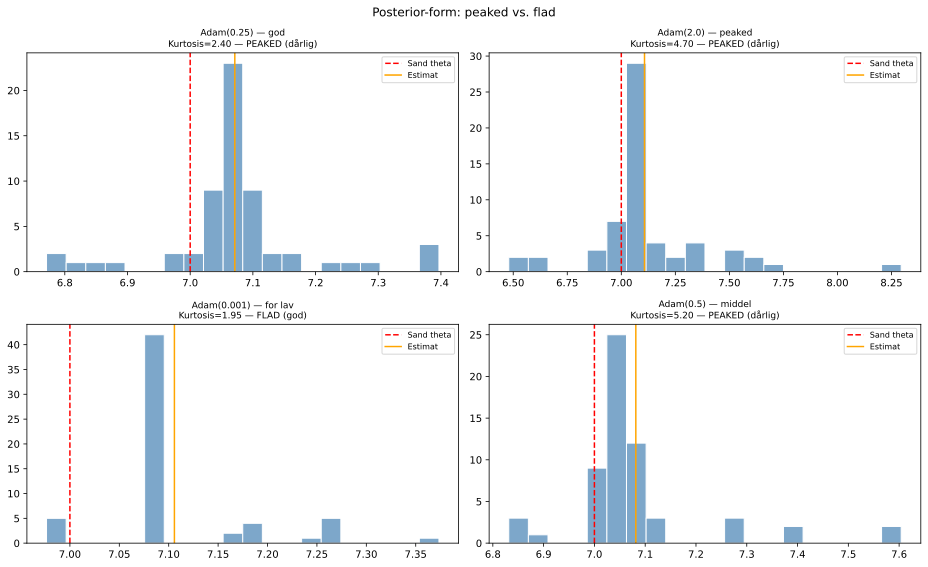

In [ ]:
#| label: fig-posterior-form
#| fig-cap: "Sammenligning af peaked vs. flad posterior under varierende konfigurationer."

from scipy.stats import kurtosis
import matplotlib.pyplot as plt
import numpy as np
from phasic import Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior
from phasic import Adam, ExpStepSize, ConstantStepSize

nr_s = 4
@with_ipv([nr_s] + [0] * (nr_s - 1))
def coal_form(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy(); new[i] -= 1; new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same)]))
    return transitions

g_form = Graph(coal_form)
true_theta_form = [7.0]
g_form.update_weights(true_theta_form)
data_form = g_form.sample(2000)

configs = {
    'Adam(0.25) — god':      {'optimizer_fn': lambda: Adam(0.25),   'n_iter': 300},
    'Adam(2.0) — peaked':    {'optimizer_fn': lambda: Adam(2.0),    'n_iter': 300},
    'Adam(0.001) — for lav': {'optimizer_fn': lambda: Adam(0.001),  'n_iter': 300},
    'Adam(0.5) — middel':    {'optimizer_fn': lambda: Adam(0.5),    'n_iter': 300},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
prior_form = DataPrior(g_form, data_form)

for ax, (name, cfg) in zip(axes.flat, configs.items()):
    sv = g_form.svgd(data_form, prior=prior_form,
                     optimizer=cfg['optimizer_fn'](),   
                     n_particles=60, n_iterations=cfg['n_iter'])
    particles = sv.get_results()['particles'].flatten()
    kurt = kurtosis(particles)
    ax.hist(particles, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(true_theta_form[0], color='red', linestyle='--', label='Sand theta')
    ax.axvline(float(particles.mean()), color='orange', linestyle='-', label='Estimat')
    peaked = 'PEAKED (dårlig)' if kurt > 2 else 'FLAD (god)'
    ax.set_title(f'{name}\nKurtosis={kurt:.2f} — {peaked}', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Posterior-form: peaked vs. flad', fontsize=12)
plt.tight_layout()
plt.show()

## Custom optimizer

Her sammenlignes forskellige optimizer-strategier systematisk, herunder muligheden for at definere sin egen læringsrate-kurve.

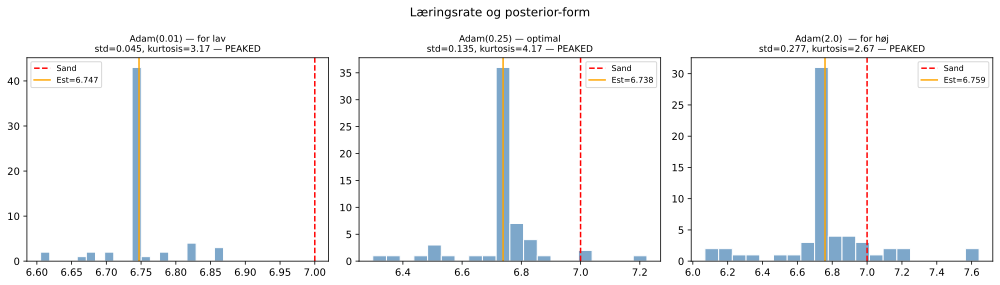

In [26]:
#| label: fig-custom-optimizer
#| fig-cap: "Custom optimizer: sammenligning af Adam med varierende læringsrater."
from phasic import Adam, DataPrior
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
import numpy as np

optimizers = {
    'Adam(0.01) — for lav':  lambda: Adam(0.01),
    'Adam(0.25) — optimal':  lambda: Adam(0.25),
    'Adam(2.0)  — for høj':  lambda: Adam(2.0),
}

g_opt = Graph(coal_form)
g_opt.update_weights([7.0])
data_opt = g_opt.sample(2000)
prior_opt = DataPrior(g_opt, data_opt)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, opt_fn) in zip(axes, optimizers.items()):
    sv = g_opt.svgd(data_opt, prior=prior_opt, optimizer=opt_fn(),
                    n_particles=60, n_iterations=300)
    particles = sv.get_results()['particles'].flatten()
    kurt = kurtosis(particles)
    mean = float(particles.mean())
    std  = float(particles.std())
    peaked = 'PEAKED' if kurt > 2 else 'FLAD'
    ax.hist(particles, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(7.0,  color='red',    linestyle='--', label='Sand')
    ax.axvline(mean, color='orange', linestyle='-',  label=f'Est={mean:.3f}')
    ax.set_title(f'{name}\nstd={std:.3f}, kurtosis={kurt:.2f} — {peaked}', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Læringsrate og posterior-form', fontsize=12)
plt.tight_layout()
plt.show()